## 2D CSA - Splitting Radially

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect

In [13]:
np.random.seed(0)

### Data Simulation

In [14]:
def simulate_scores(n_phages, mean1, mean2, correlation, variance):
    """
    Simulates scores. We use a smaller variance (0.01) to make the 
    L-shape look 'sharp' like your image.
    """
    mean = [mean1, mean2]
   
    cov = [[variance, correlation * variance], [correlation * variance, variance]]  
    
    # Using absolute values to only have the postive quadrant
    scores = np.abs(np.random.multivariate_normal(mean, cov, n_phages))
    return np.clip(scores, 0, 1)

### Data Splitting

In [15]:
def split_calibration_data(scores, split_ratio):
    """
    Splits ths calibration scores
    """
    n = len(scores)
    indices = np.arange(n)
    np.random.shuffle(indices)  
    limit = int(n * split_ratio)
    # randomly splits the indices into 2 sets
    return scores[indices[:limit]], scores[indices[limit:]]

#### Shape Discovery Set

In [16]:
def shape_discovery(shape_set_scores, alpha, M, delta_deg=10):
    """
    Discovers the shape of the envelope using the shape set scores
    We take M preojection directions, then for each direction we find the points that are close to it using a cosine
    similarity threshold (i.e. points that are within delts_deg of the direction).
    We then compute the local 1-alpha quantile of the magnitudes of the scores in that region to get tilde[m]
    """

    # Creating M projection directions
    angles = np.linspace(0, np.pi/2, M)
    u_directions = np.vstack([np.cos(angles), np.sin(angles)]).T
    
    # Calculating the magnitudes of all scores
    magnitudes = np.linalg.norm(shape_set_scores, axis=1)
    # Normalizing the scores to get their directions
    score_dirs = shape_set_scores / (magnitudes[:, None] + 1e-12)
    
    cos_threshold = np.cos(np.radians(delta_deg))
    q_tilde = np.zeros(M)

    for m in range(M):
        # Finding points that are "close" to this direction u_m
        similarities = score_dirs @ u_directions[m]
        local_mask = similarities >= cos_threshold
        
        # If there are no points that are close, use a very small value or expand delta
        if np.sum(local_mask) < 5: 
            q_tilde[m] = 0.01 
        else:
            # Otherwise we calculate the local 1-alpha% quantile of magnitudes
            q_tilde[m] = np.quantile(magnitudes[local_mask], 1 - alpha)
            
    return u_directions, q_tilde

### Size Scaling

In [17]:
def size_scaling(size_set_scores, u_directions, q_tilde, alpha):
    """
    Scales the envelope while ensuring monotonicity (star-shape).
    A score is inside if s_x <= boundary_x AND s_y <= boundary_y 
    for at least one of our M boundary points.
    """
    # 2D coordinated of our boundary in each direction
    boundary_coords = u_directions * q_tilde[:, None]
    
    # We find the 'best' t for each score point.
    # For a specific direction m, t_m = max(s_x / boundary_x_m, s_y / boundary_y_m)
    # The overall t*(s) is the minimum of these t_m across all directions since the point only needs to be "covered" by ONE sector.

    # s_dim / boundary_dim for both x and y (shape: N, M, 2)
    ratios = size_set_scores[:, None, :] / (boundary_coords[None, :, :] + 1e-12)
    
    # Max over dimensions (x, y) to ensure both coords are covered by that sector
    t_per_sector = np.max(ratios, axis=2) 
    
    # Min over sectors: point s is inside if ANY sector covers it
    tau_scores = np.min(t_per_sector, axis=1)
    
    n2 = len(tau_scores)
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]
    
    return t_hat, tau_scores

In [18]:
# # --- 4. Size Scaling ---
# def size_scaling(size_set_scores, u_directions, q_tilde, alpha):
#     """
#     Scales the size of the envelope using the size set scores
#     """
#     # Calculating the magnitudes of all the scores  
#     magnitudes = np.linalg.norm(size_set_scores, axis=1)
#     score_dirs = size_set_scores / (magnitudes[:, None] + 1e-12)
    
#     # For each point, we find the direction u_m it is closest to
#     # This basically assignseach point to its specific sector
#     best_dir_idx = np.argmax(score_dirs @ u_directions.T, axis=1)
    
#     # tau is the ratio of the point's magnitude to the local sector's quantile
#     tau_scores = magnitudes / (q_tilde[best_dir_idx] + 1e-12)
    
#     n2 = len(tau_scores)
#     idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
#     t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]
    
#     return t_hat, tau_scores

### Visualization

In [19]:
def plot_csa_steps(scores, S1, S2, u_directions, q_tilde, t_hat, alpha, p = 0.5):
    """
    Plots the steps of the CSA
    """

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    x_range = np.linspace(0, 1, 200) 
    X, Y = np.meshgrid(x_range, x_range)
    grid = np.vstack([X.ravel(), Y.ravel()]).T

    # For each grid point, we find the direction u_m it is the closest to (i.e. which sector it belongs to)
    grid_mags = np.linalg.norm(grid, axis=1)
    grid_dirs = grid / (grid_mags[:, None] + 1e-12)

    # Plotting the original score distribution
    axs[0].scatter(scores[:, 0], scores[:, 1], color='black', alpha=0.5, s=10)
    axs[0].set_title('Score Distribution')


    def get_star_mask(points, directions, quantiles):
        # boundary_coords.shape = (M, 2)
        boundary_coords = directions * quantiles[:, None]
        # Check if point is <= boundary point for ANY of the M sectors
        # points[:, None, 0] compares every point to every boundary x-coord
        is_inside = np.any(
            (points[:, None, 0] <= boundary_coords[None, :, 0]) & 
            (points[:, None, 1] <= boundary_coords[None, :, 1]), 
            axis=1
        )
        return is_inside

    # Shape discovery 
    # Applying the radial check ) ()nagnitude <= local sector quantile)
    inside_shape_vec = get_star_mask(grid, u_directions, q_tilde)
    inside_shape = inside_shape_vec.reshape(X.shape)


    axs[1].contourf(X, Y, inside_shape, levels=[0.5, 1], colors='blue', alpha=0.2)
    axs[1].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linewidths=2)
    axs[1].scatter(S1[:, 0], S1[:, 1], color='blue', alpha=0.5, s=10)
    axs[1].set_title('Shape Discovery (S1)')


    # Final scaled region after size scaling
    q_final = q_tilde * t_hat
    inside_final_vec = get_star_mask(grid, u_directions, q_final)
    inside_final = inside_final_vec.reshape(X.shape)

  
    axs[2].contourf(X, Y, inside_final, levels=[0.5, 1], colors='green', alpha=0.2)
    axs[2].contour(X, Y, inside_final, levels=[0.5], colors='green', linewidths=2)
    axs[2].scatter(S2[:, 0], S2[:, 1],color='green', alpha=0.5, s=10)

    axs[2].scatter(S1[:, 0], S1[:, 1], color='blue', alpha=0.5, s=10)
    axs[2].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linestyles='--', linewidths=1.5)

    axs[2].set_title(f'Final Calibrated Region (t={t_hat:.2f})')
 
    for ax in axs:
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout()

In [20]:
# def plot_csa_steps(scores, S1, S2, u_directions, q_tilde, t_hat, alpha):
#     """
#     Plots the steps of the CSA
#     """

#     fig, axs = plt.subplots(1, 3, figsize=(18, 5))
#     x_range = np.linspace(0, 1, 200) 
#     X, Y = np.meshgrid(x_range, x_range)
#     grid = np.vstack([X.ravel(), Y.ravel()]).T

#     # For each grid point, we find the direction u_m it is the closest to (i.e. which sector it belongs to)
#     grid_mags = np.linalg.norm(grid, axis=1)
#     grid_dirs = grid / (grid_mags[:, None] + 1e-12)
    
#     # Finding which sector each grid point belongs to
#     closest_u_idx = np.argmax(grid_dirs @ u_directions.T, axis=1)

#     # Plotting the original score distribution
#     axs[0].scatter(scores[:, 0], scores[:, 1], color='black', alpha=0.5)
#     axs[0].set_title('Score Distribution')
#     axs[0].set_xlim(-0.02, 0.8); axs[0].set_ylim(-0.02, 0.8)

#     # Shape discovery 
#     # Applying the radial check ) ()nagnitude <= local sector quantile)
#     inside_shape = (grid_mags <= q_tilde[closest_u_idx]).reshape(X.shape)
    
#     axs[1].contourf(X, Y, inside_shape, levels=[0.5, 1], colors='blue', alpha=0.2)
#     axs[1].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linewidths=2)
#     axs[1].scatter(S1[:, 0], S1[:, 1], color='blue', alpha=0.5)
#     axs[1].set_title('Shape Discovery (S1)')
#     axs[1].set_xlim(-0.02, 0.8); axs[1].set_ylim(-0.02, 0.8)

#     # Final scaled region after size scaling
#     q_final = q_tilde * t_hat
#     # Applying the radial check: Magnitude <= scaled local sector quantile
#     inside_final = (grid_mags <= q_final[closest_u_idx]).reshape(X.shape)
  
#     axs[2].contourf(X, Y, inside_final, levels=[0.5, 1], colors='green', alpha=0.2)
#     axs[2].contour(X, Y, inside_final, levels=[0.5], colors='green', linewidths=2)
#     axs[2].scatter(S2[:, 0], S2[:, 1],color='green', alpha=0.5)

#     axs[2].scatter(S1[:, 0], S1[:, 1], color='blue', alpha=0.4)
#     axs[2].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linestyles='--', linewidths=1.5)

#     axs[2].set_title(f'Final Calibrated Region (t={t_hat:.2f})')
#     axs[2].set_xlim(-0.02, 0.8); axs[2].set_ylim(-0.02, 0.8)

#     plt.tight_layout()

### Executing

In [21]:
alpha = 0.1 
M = 500      

# # Simulating the scores (L-shaped)
# origin = simulate_scores(100, mean1=0.0, mean2=0.0, correlation=0, variance=0.01)
# # Model 1 accurate, Model 2 failing
# arm_y = simulate_scores(150, mean1=0.0, mean2=0.4, correlation=0, variance=0.007)
# # Model 2 accurate, Model 1 failing
# arm_x = simulate_scores(150, mean1=0.4, mean2=0.0, correlation=0, variance=0.007)
# raw_scores = np.vstack([origin, arm_y, arm_x])

# Simulating scores (correlated = diagonal)
raw_scores = simulate_scores(500, mean1 = 0.3, mean2 = 0.3, correlation= 0.8, variance = 0.02)

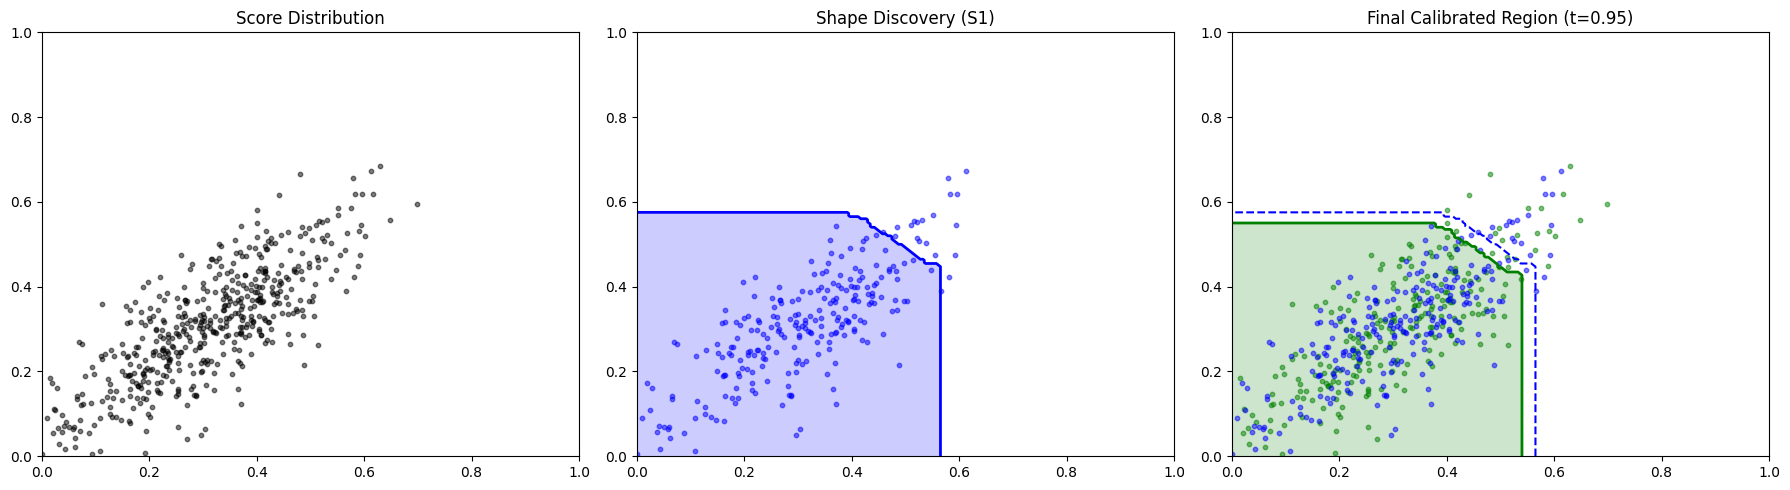

In [22]:
S1, S2 = split_calibration_data(raw_scores, split_ratio=0.5)
u_directions, q_tilde = shape_discovery(S1, alpha, M)
t_hat, tau_scores = size_scaling(S2, u_directions, q_tilde, alpha)

plot_csa_steps(raw_scores, S1, S2, u_directions, q_tilde, t_hat, alpha)